In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/annotations/scratches_246.xml
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/annotations/patches_258.xml
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/annotations/crazing_241.xml
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/annotations/patches_267.xml
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/annotations/crazing_270.xml
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/annotations/pitted_surface_256.xml
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/annotations/pitted_surface_265.xml
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET/validation/annotations/pitted_surface_287.xml
/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-databas

# 环境配置

In [3]:
import os
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

# 数据探索

In [4]:
DATASET_ROOT = "/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET"

OUTPUT_ROOT = "/kaggle/working/NEU_YOLO"

IMAGE_SIZE = 200

In [5]:
CLASS_MAP = {
    "crazing": 0,
    "inclusion": 1,
    "patches": 2,
    "pitted_surface": 3,
    "rolled-in_scale": 4,
    "scratches": 5
}

# 数据格式转换

In [6]:
def find_image(image_root, filename):

    for path in Path(image_root).rglob(filename):
        return str(path)

    return None

In [7]:
def xml_to_yolo(xml_file, save_txt):

    tree = ET.parse(xml_file)
    root = tree.getroot()

    lines = []

    for obj in root.findall("object"):

        cls = obj.find("name").text

        if cls not in CLASS_MAP:
            continue

        cls_id = CLASS_MAP[cls]

        box = obj.find("bndbox")

        xmin = float(box.find("xmin").text)
        ymin = float(box.find("ymin").text)
        xmax = float(box.find("xmax").text)
        ymax = float(box.find("ymax").text)

        x = (xmin + xmax) / 2 / IMAGE_SIZE
        y = (ymin + ymax) / 2 / IMAGE_SIZE
        w = (xmax - xmin) / IMAGE_SIZE
        h = (ymax - ymin) / IMAGE_SIZE

        lines.append(
            f"{cls_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}"
        )

    with open(save_txt, "w") as f:
        f.write("\n".join(lines))

In [8]:
def make_dirs():

    folders = [

        "images/train",
        "images/val",

        "labels/train",
        "labels/val"

    ]

    for folder in folders:

        os.makedirs(
            os.path.join(OUTPUT_ROOT, folder),
            exist_ok=True
        )

In [9]:
def process_split(split):

    print(f"\n开始处理 {split} 数据集...")

    annotation_dir = os.path.join(
        DATASET_ROOT,
        split,
        "annotations"
    )

    image_root = os.path.join(
        DATASET_ROOT,
        split,
        "images"
    )

    image_save = os.path.join(
        OUTPUT_ROOT,
        "images",
        "train" if split == "train" else "val"
    )

    label_save = os.path.join(
        OUTPUT_ROOT,
        "labels",
        "train" if split == "train" else "val"
    )

    xml_files = sorted(os.listdir(annotation_dir))

    success = 0

    for xml in xml_files:

        xml_path = os.path.join(annotation_dir, xml)

        jpg_name = xml.replace(".xml", ".jpg")

        image_path = find_image(image_root, jpg_name)

        if image_path is None:
            print("找不到图片：", jpg_name)
            continue

        shutil.copy(image_path, image_save)

        txt_path = os.path.join(
            label_save,
            xml.replace(".xml", ".txt")
        )

        xml_to_yolo(xml_path, txt_path)

        success += 1

    print(f"{split} 完成：{success} 张")

In [10]:
if __name__ == "__main__":

    make_dirs()

    process_split("train")
    process_split("validation")

    print("\n全部完成！")


开始处理 train 数据集...
train 完成：1439 张

开始处理 validation 数据集...
找不到图片： crazing_240.jpg
validation 完成：360 张

全部完成！


# 数据质量检查

## Step 1：检查图片和标签数量

In [11]:
root = "/kaggle/working/NEU_YOLO"

for split in ['train', 'val']:
    image_dir = os.path.join(root, 'images', split)
    label_dir = os.path.join(root, 'labels', split)

    image_num = len(os.listdir(image_dir))
    label_num = len(os.listdir(label_dir))

    print(f"{split}")
    print("图片：", image_num)
    print("标签：", label_num)
    print("-"*30)

train
图片： 1439
标签： 1439
------------------------------
val
图片： 360
标签： 360
------------------------------


## Step 2：检查标签格式

In [12]:
label_root = '/kaggle/working/NEU_YOLO/labels'

error = 0

for split in ["train", "val"]:
    folder = os.path.join(label_root, split)

    for txt in os.listdir(folder):
        txt_path = os.path.join(folder, txt)

        with open(txt_path) as f:
            lines = f.readlines()

        for line in lines:
            data = line.strip().split()

            if len(data) != 5:
                print("格式错误：", txt)
                error += 1
print("错误数量：", error)

错误数量： 0


## Step 3：检查坐标有没有越界

In [13]:
label_root = "/kaggle/working/NEU_YOLO/labels"

bad = 0

for split in ["train", "val"]:

    folder = os.path.join(label_root, split)

    for txt in os.listdir(folder):

        txt_path = os.path.join(folder, txt)

        with open(txt_path) as f:

            for line in f:

                cls, x, y, w, h = map(float, line.split())

                if not (0 <= x <= 1):
                    bad += 1

                if not (0 <= y <= 1):
                    bad += 1

                if not (0 <= w <= 1):
                    bad += 1

                if not (0 <= h <= 1):
                    bad += 1

print("越界数量：", bad)

越界数量： 0


## Step 4：随机可视化 5 张图片

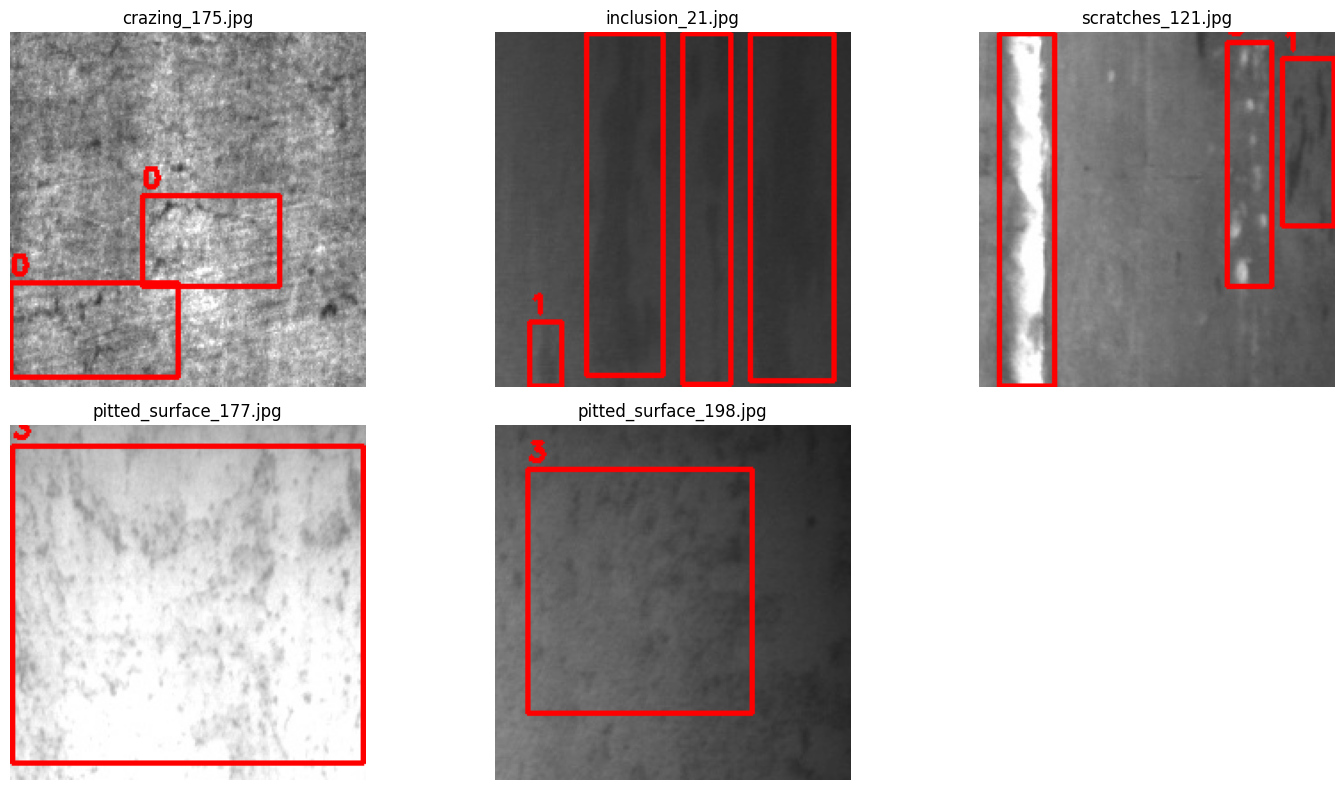

In [14]:
import os
import random
import cv2
import matplotlib.pyplot as plt

ROOT = "/kaggle/working/NEU_YOLO"
image_dir = os.path.join(ROOT, "images", "train")
label_dir = os.path.join(ROOT, "labels", "train")

images = os.listdir(image_dir)

sample_images = random.sample(images, 5)

plt.figure(figsize=(15,8))

for i, image_name in enumerate(sample_images):

    img_path = os.path.join(image_dir, image_name)
    txt_path = os.path.join(
        label_dir,
        image_name.replace(".jpg", ".txt")
    )

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]

    with open(txt_path) as f:
        for line in f:
            cls, xc, yc, bw, bh = map(float, line.split())

            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)

            cv2.rectangle(
                img,
                (x1, y1),
                (x2, y2),
                (255,0,0),
                2
            )

            cv2.putText(
                img,
                str(int(cls)),
                (x1,y1-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255,0,0),
                2
            )

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(image_name)

plt.tight_layout()
plt.show()

# 创建data.yaml，确认YOLO环境

In [15]:
yaml_content = """
path: /kaggle/working/NEU_YOLO

train: images/train
val: images/val

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches
"""
with open("/kaggle/working/data.yaml", 'w') as f:
    f.write(yaml_content)

print("data.yaml 创建完成！")

data.yaml 创建完成！


In [16]:
with open("/kaggle/working/data.yaml") as f:
    print(f.read())


path: /kaggle/working/NEU_YOLO

train: images/train
val: images/val

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches



In [17]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [18]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.7 MB/s eta 0:00:00a 0:00:01


In [19]:
from ultralytics import YOLO

print("YOLO 导入成功！")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO 导入成功！


# 开始训练 YOLOv8（Baseline）

In [20]:
from ultralytics import YOLO

# 选择最轻量模型（适合baseline）
model = YOLO('yolov8n.pt')

model.train(
    data = "/kaggle/working/data.yaml",
    epochs = 20,
    imgsz = 640,
    batch = 16,
    device = 0,
    project="/kaggle/working/runs",
    name="neu_defect_yolov8n"
)

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=neu_defect_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f7b72aeae40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [21]:
import os

exp_path = "/kaggle/working/runs"

for root, dirs, files in os.walk(exp_path):
    for f in files:
        if f.endswith(".png") or f.endswith(".csv") or f.endswith(".pt"):
            print(os.path.join(root, f))

/kaggle/working/runs/neu_defect_yolov8n/BoxR_curve.png
/kaggle/working/runs/neu_defect_yolov8n/BoxP_curve.png
/kaggle/working/runs/neu_defect_yolov8n/confusion_matrix.png
/kaggle/working/runs/neu_defect_yolov8n/results.png
/kaggle/working/runs/neu_defect_yolov8n/BoxF1_curve.png
/kaggle/working/runs/neu_defect_yolov8n/results.csv
/kaggle/working/runs/neu_defect_yolov8n/BoxPR_curve.png
/kaggle/working/runs/neu_defect_yolov8n/confusion_matrix_normalized.png
/kaggle/working/runs/neu_defect_yolov8n/weights/best.pt
/kaggle/working/runs/neu_defect_yolov8n/weights/last.pt


# 推理可视化
## ✅ 1. 随机挑几张测试图片
## ✅ 2. 用 YOLO 进行预测
## ✅ 3. 把检测结果画出来（框 + 类别 + 置信度）

In [22]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/neu_defect_yolov8n/weights/best.pt")

print("模型加载成功！")

模型加载成功！


In [23]:
test_img = "/kaggle/working/NEU_YOLO/images/val"

results = model.predict(
    source = test_img,
    save = True,
    conf = 0.25
)
print("推理完成！")


image 1/360 /kaggle/working/NEU_YOLO/images/val/crazing_241.jpg: 640x640 2 crazings, 9.7ms
image 2/360 /kaggle/working/NEU_YOLO/images/val/crazing_242.jpg: 640x640 2 crazings, 7.2ms
image 3/360 /kaggle/working/NEU_YOLO/images/val/crazing_243.jpg: 640x640 1 crazing, 7.2ms
image 4/360 /kaggle/working/NEU_YOLO/images/val/crazing_244.jpg: 640x640 1 crazing, 7.2ms
image 5/360 /kaggle/working/NEU_YOLO/images/val/crazing_245.jpg: 640x640 1 crazing, 7.2ms
image 6/360 /kaggle/working/NEU_YOLO/images/val/crazing_246.jpg: 640x640 2 crazings, 7.2ms
image 7/360 /kaggle/working/NEU_YOLO/images/val/crazing_247.jpg: 640x640 2 crazings, 7.2ms
image 8/360 /kaggle/working/NEU_YOLO/images/val/crazing_248.jpg: 640x640 2 crazings, 7.2ms
image 9/360 /kaggle/working/NEU_YOLO/images/val/crazing_249.jpg: 640x640 1 crazing, 7.2ms
image 10/360 /kaggle/working/NEU_YOLO/images/val/crazing_250.jpg: 640x640 4 crazings, 7.2ms
image 11/360 /kaggle/working/NEU_YOLO/images/val/crazing_251.jpg: 640x640 (no detections), 7


image 1/1 /kaggle/working/NEU_YOLO/images/val/inclusion_265.jpg: 640x640 5 inclusions, 8.7ms
Speed: 2.8ms preprocess, 8.7ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/rolled-in_scale_272.jpg: 640x640 3 rolled-in_scales, 7.2ms
Speed: 2.0ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/rolled-in_scale_242.jpg: 640x640 1 rolled-in_scale, 7.2ms
Speed: 1.9ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/patches_294.jpg: 640x640 3 patchess, 7.2ms
Speed: 2.1ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/scratches_299.jpg: 640x640 2 scratchess, 7.2ms
Speed: 1.9ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


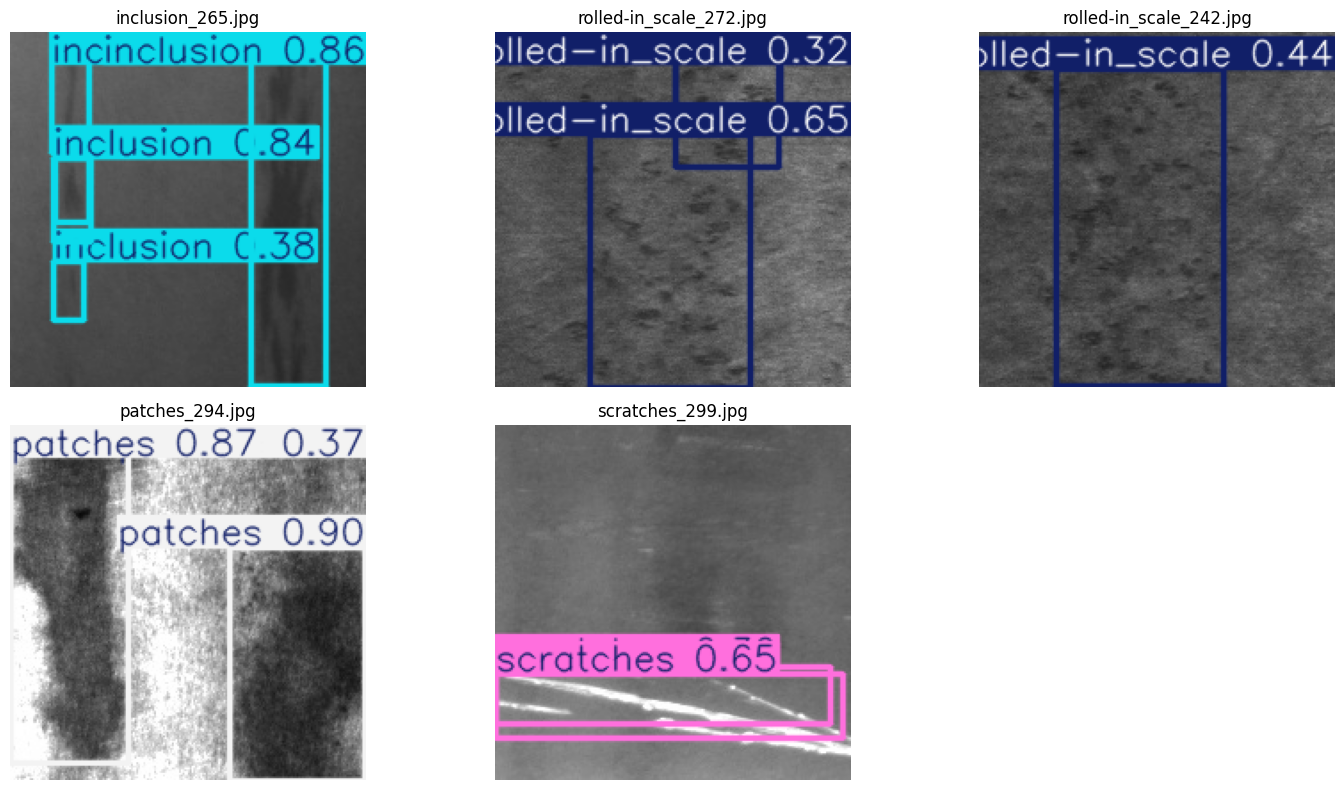

In [24]:
import os
import random
import matplotlib.pyplot as plt
import cv2

img_dir = "/kaggle/working/NEU_YOLO/images/val"
imgs = os.listdir(img_dir)

sample_imgs = random.sample(imgs, 5)

plt.figure(figsize = (15, 8))

for i, img_name in enumerate(sample_imgs):
    path = os.path.join(img_dir, img_name)

    results = model(path)

    img = results[0].plot()   # YOLO自动画框（关键）

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(img_name)

plt.tight_layout()
plt.show()

# 错误分析+模型理解

## Step 1：看单张预测结果结构

In [27]:
results = model("/kaggle/working/NEU_YOLO/images/val/crazing_261.jpg")

r = results[0]
print(r.boxes)
print('=' * 50)
print(r.boxes.cls)
print('=' * 50)
print(r.boxes.conf)


image 1/1 /kaggle/working/NEU_YOLO/images/val/crazing_261.jpg: 640x640 1 crazing, 8.7ms
Speed: 3.1ms preprocess, 8.7ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0.], device='cuda:0')
conf: tensor([0.2880], device='cuda:0')
data: tensor([[3.1559e+01, 1.1701e-01, 1.9205e+02, 6.3886e+01, 2.8801e-01, 0.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (200, 200)
shape: torch.Size([1, 6])
xywh: tensor([[111.8068,  32.0014, 160.4950,  63.7687]], device='cuda:0')
xywhn: tensor([[0.5590, 0.1600, 0.8025, 0.3188]], device='cuda:0')
xyxy: tensor([[3.1559e+01, 1.1701e-01, 1.9205e+02, 6.3886e+01]], device='cuda:0')
xyxyn: tensor([[1.5780e-01, 5.8506e-04, 9.6027e-01, 3.1943e-01]], device='cuda:0')
tensor([0.], device='cuda:0')
tensor([0.2880], device='cuda:0')


## Step 2：统计模型“偏好”
### 哪些类别最容易被预测出来 / 最难

In [28]:
from collections import Counter

all_cls = []

for img_name in os.listdir("/kaggle/working/NEU_YOLO/images/val"):
    path = os.path.join("/kaggle/working/NEU_YOLO/images/val", img_name)
    results = model(path)
    r = results[0]

    if r.boxes is not None:
        cls_list = r.boxes.cls.cpu().numpy().astype(int)
        all_cls.extend(cls_list)

Counter(all_cls)


image 1/1 /kaggle/working/NEU_YOLO/images/val/pitted_surface_293.jpg: 640x640 1 pitted_surface, 11.6ms
Speed: 3.5ms preprocess, 11.6ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/rolled-in_scale_297.jpg: 640x640 1 rolled-in_scale, 7.4ms
Speed: 2.4ms preprocess, 7.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/scratches_256.jpg: 640x640 1 scratches, 7.2ms
Speed: 2.1ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/patches_266.jpg: 640x640 6 patchess, 7.2ms
Speed: 1.8ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/crazing_298.jpg: 640x640 (no detections), 7.2ms
Speed: 1.8ms preprocess, 7.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_Y

Counter({np.int64(3): 76,
         np.int64(4): 149,
         np.int64(5): 166,
         np.int64(2): 227,
         np.int64(0): 70,
         np.int64(1): 202})

## Step 3：错误案例分析

In [29]:
missed = []

img_dir = "/kaggle/working/NEU_YOLO/images/val"

for img_name in os.listdir(img_dir):
    path = os.path.join(img_dir, img_name)
    results = model(path)

    r = results[0]

    if r.boxes is None or len(r.boxes) == 0:
        missed.append(img_name)

print("漏检样本数量：", len(missed))
print(missed[:10])


image 1/1 /kaggle/working/NEU_YOLO/images/val/pitted_surface_293.jpg: 640x640 1 pitted_surface, 10.4ms
Speed: 2.7ms preprocess, 10.4ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/rolled-in_scale_297.jpg: 640x640 1 rolled-in_scale, 7.2ms
Speed: 1.9ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/scratches_256.jpg: 640x640 1 scratches, 7.5ms
Speed: 2.4ms preprocess, 7.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/patches_266.jpg: 640x640 6 patchess, 7.2ms
Speed: 2.1ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/crazing_298.jpg: 640x640 (no detections), 7.2ms
Speed: 2.0ms preprocess, 7.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_Y

## Step 4：检查低置信度预测（误检预测）

In [30]:
false_positive_samples = []

for img_name in os.listdir(img_dir):
    path = os.path.join(img_dir, img_name)
    results = model(path)

    r = results[0]

    if r.boxes is not None:
        confs = r.boxes.conf.cpu().numpy()

        # 如果有很低置信度预测
        if any(confs < 0.3):
            false_positive_samples.append(img_name)

print("可能误检样本:", len(false_positive_samples))
print(false_positive_samples[:10])


image 1/1 /kaggle/working/NEU_YOLO/images/val/pitted_surface_293.jpg: 640x640 1 pitted_surface, 7.8ms
Speed: 2.4ms preprocess, 7.8ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/rolled-in_scale_297.jpg: 640x640 1 rolled-in_scale, 7.2ms
Speed: 2.1ms preprocess, 7.2ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/scratches_256.jpg: 640x640 1 scratches, 7.2ms
Speed: 1.9ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/patches_266.jpg: 640x640 6 patchess, 7.2ms
Speed: 2.0ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/crazing_298.jpg: 640x640 (no detections), 7.2ms
Speed: 2.2ms preprocess, 7.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOL

## Step 3：找 confusion matrix 对应问题

In [31]:
import numpy as np
from collections import defaultdict

confusion_errors = defaultdict(int)

for img_name in os.listdir(img_dir):
    path = os.path.join(img_dir, img_name)
    results = model(path)

    r = results[0]

    if r.boxes is not None:
        pred_cls = r.boxes.cls.cpu().numpy().astype(int)

        for c in pred_cls:
            confusion_errors[c] += 1

print(confusion_errors)


image 1/1 /kaggle/working/NEU_YOLO/images/val/pitted_surface_293.jpg: 640x640 1 pitted_surface, 10.0ms
Speed: 2.6ms preprocess, 10.0ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/rolled-in_scale_297.jpg: 640x640 1 rolled-in_scale, 7.6ms
Speed: 1.9ms preprocess, 7.6ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/scratches_256.jpg: 640x640 1 scratches, 7.2ms
Speed: 2.5ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/patches_266.jpg: 640x640 6 patchess, 7.2ms
Speed: 1.8ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_YOLO/images/val/crazing_298.jpg: 640x640 (no detections), 7.2ms
Speed: 2.1ms preprocess, 7.2ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/NEU_Y